### Student Performance Prediction System (ML Project)

In [32]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Save model
import pickle

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load dataset
df = pd.read_csv("student_performance_dataset.csv")

In [4]:
df.head()

,hours_study,attendance,internal_marks,previous_cgpa,participation,final_score
0,4.745071,83.577874,17.027862,7.756989,2,37.582168
1,3.792604,85.607845,22.003125,6.077835,3,37.710752
2,4.971533,90.830512,25.026218,7.869606,2,44.441500
3,6.284545,90.538021,25.234903,8.355638,1,43.184269
4,3.648770,66.223306,22.749673,7.413435,3,32.983929


In [5]:
df.tail()

,hours_study,attendance,internal_marks,previous_cgpa,participation,final_score
195,4.577976,75.308243,22.449918,8.053153,5,49.101488
196,2.674214,62.868655,23.650625,6.960445,3,32.573598
197,4.230588,93.538724,20.106181,7.681501,3,41.948323
198,4.087313,78.854602,22.778534,7.028318,2,40.959796
199,2.285545,92.378163,26.886502,7.029756,1,41.576518


In [6]:
df.shape

(200, 6)

In [7]:
df.columns

Index(['hours_study', 'attendance', 'internal_marks', 'previous_cgpa',
       'participation', 'final_score'],
      dtype='object')

In [8]:
df.dtypes

hours_study       float64
attendance        float64
internal_marks    float64
previous_cgpa     float64
participation       int64
final_score       float64
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hours_study     200 non-null    float64
 1   attendance      200 non-null    float64
 2   internal_marks  200 non-null    float64
 3   previous_cgpa   200 non-null    float64
 4   participation   200 non-null    int64  
 5   final_score     200 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 9.5 KB


In [10]:
df.isnull().sum()

hours_study       0
attendance        0
internal_marks    0
previous_cgpa     0
participation     0
final_score       0
dtype: int64

In [40]:
df = df.dropna()

In [11]:
df.duplicated().sum()

0

In [12]:
df.describe()

,hours_study,attendance,internal_marks,previous_cgpa,participation,final_score
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,3.938844,80.720650,24.192285,7.008967,3.020000,38.084932
std,1.396506,9.434533,4.319208,1.019574,1.456091,5.996400
min,0.070382,50.000000,12.641777,4.303113,1.000000,19.334343
25%,2.942308,73.941625,21.030608,6.293531,2.000000,34.565497
50%,3.993712,80.788393,24.612000,7.022262,3.000000,38.728518
75%,4.751279,86.872311,27.860441,7.685177,4.000000,41.830238
max,8.080254,100.000000,30.000000,9.632382,5.000000,51.535428


### EDA

#### Target + outcome distribution

target: final_score
count    200.000000
mean      38.084932
std        5.996400
min       19.334343
25%       34.565497
50%       38.728518
75%       41.830238
max       51.535428
Name: final_score, dtype: float64


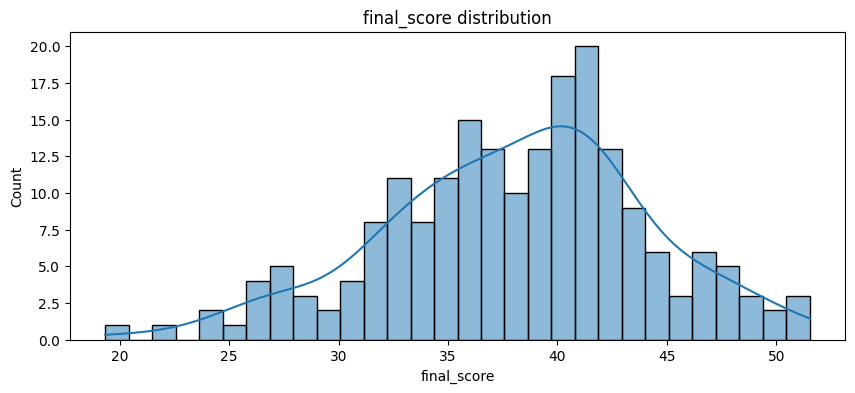

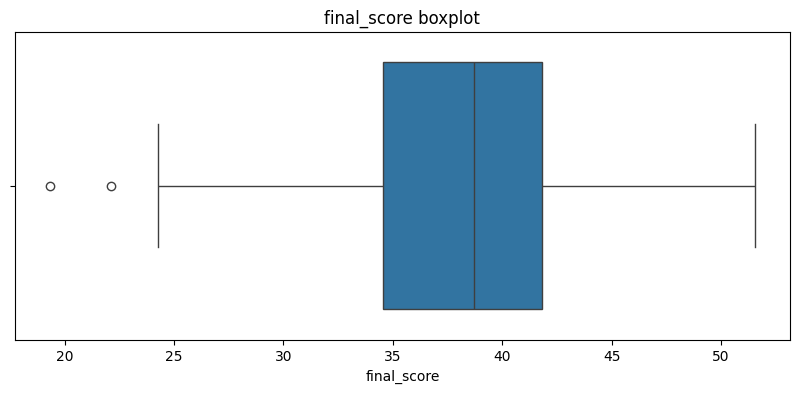

In [13]:
target_col = "average_score" if "average_score" in df.columns else df.columns[-1]
print("target:", target_col)
print(df[target_col].describe())

plt.figure(figsize=(10,4))
sns.histplot(df[target_col], kde=True, bins=30)
plt.title(f"{target_col} distribution")
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x=df[target_col])
plt.title(f"{target_col} boxplot")
plt.show()

#### Target + outcome distribution

In [14]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("categorical:", cat_cols)
print("numerical:", num_cols)

for c in cat_cols:
    print("\n", c)
    print(df[c].value_counts(dropna=False).head(15))
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=c, order=df[c].value_counts().index)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Count of {c}")
    plt.tight_layout()
    plt.show()

categorical: []
numerical: ['hours_study', 'attendance', 'internal_marks', 'previous_cgpa', 'participation', 'final_score']


#### Numerical distribution + outliers

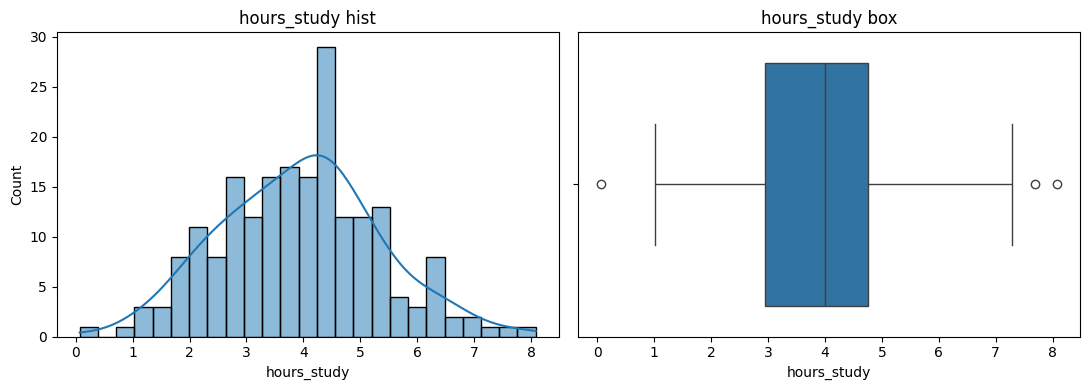

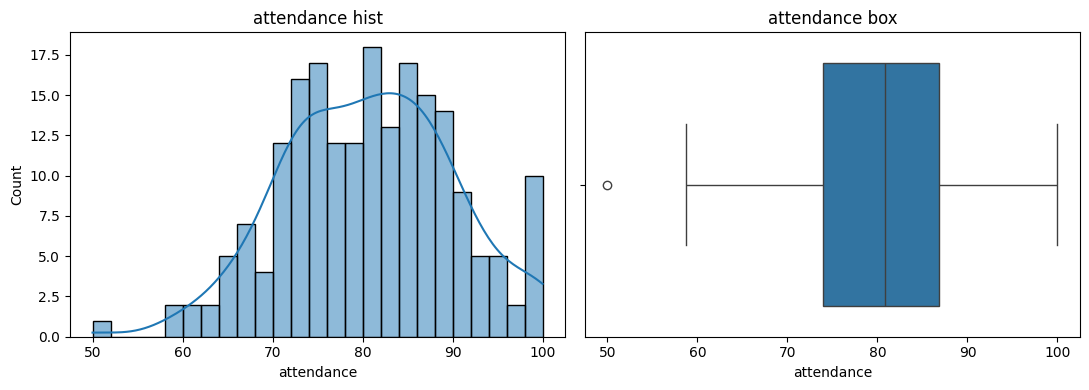

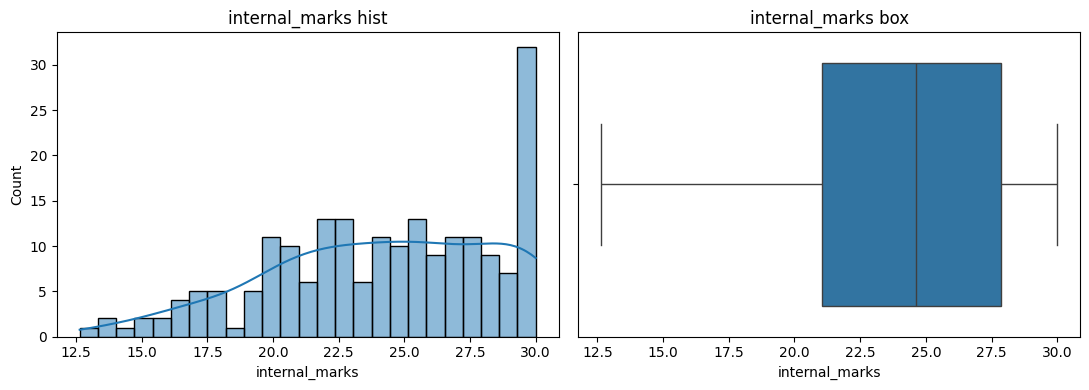

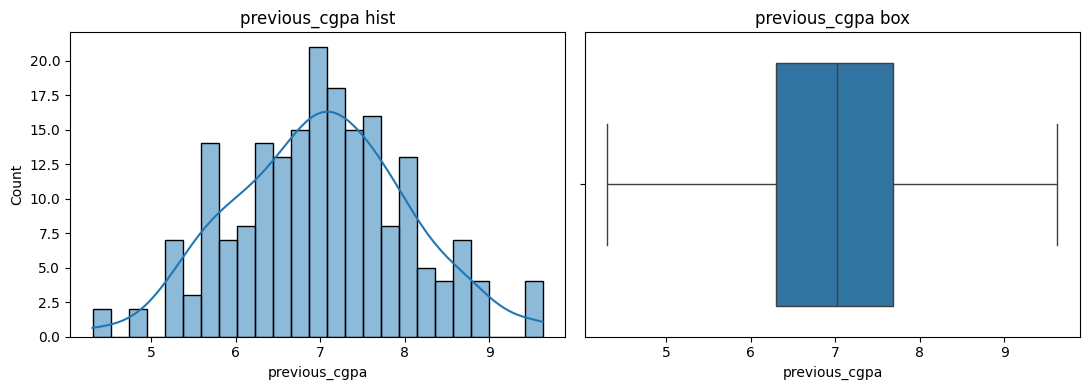

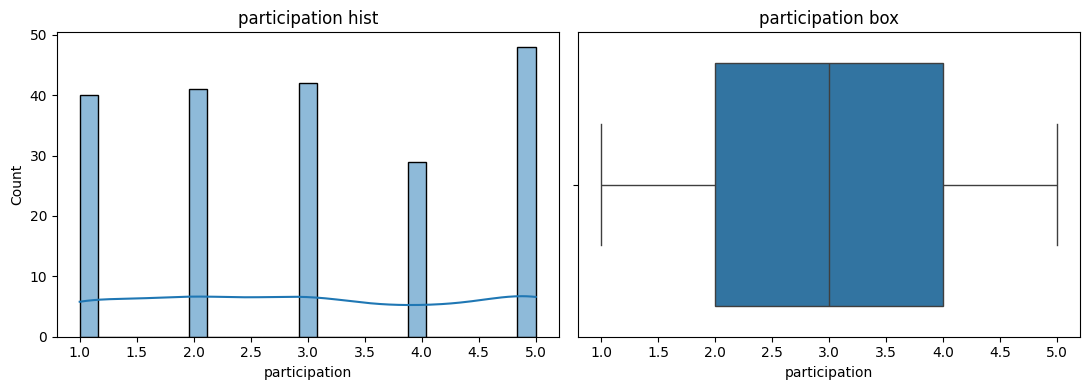

In [15]:
for c in num_cols:
    if c == target_col: continue
    plt.figure(figsize=(11,4))
    plt.subplot(1,2,1)
    sns.histplot(df[c].dropna(), bins=25, kde=True)
    plt.title(f"{c} hist")

    plt.subplot(1,2,2)
    sns.boxplot(x=df[c])
    plt.title(f"{c} box")
    plt.tight_layout()
    plt.show()

#### Correlation analysis

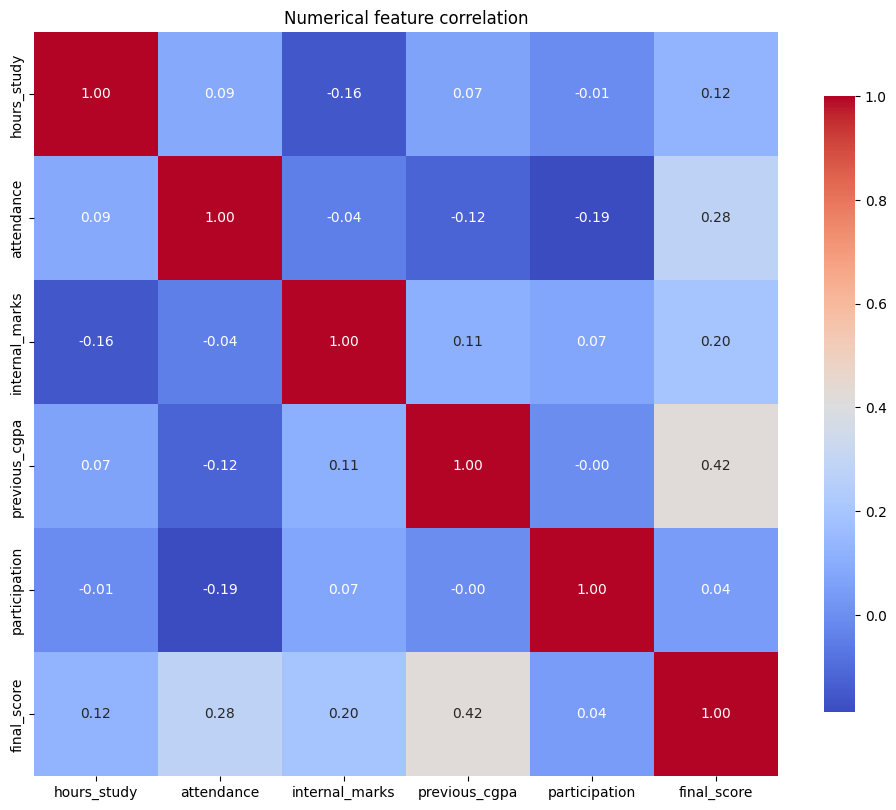

Correlation with target:
final_score       1.000000
previous_cgpa     0.423751
attendance        0.281152
internal_marks    0.197370
hours_study       0.123900
participation     0.040825
Name: final_score, dtype: float64


In [16]:
corr = df[num_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, cbar_kws={'shrink':0.8})
plt.title("Numerical feature correlation")
plt.show()

if target_col in corr:
    print("Correlation with target:")
    print(corr[target_col].sort_values(ascending=False))

#### Categorical vs target

In [17]:
if target_col in num_cols:
    for c in cat_cols:
        plt.figure(figsize=(9,4))
        sns.boxplot(data=df, x=c, y=target_col)
        plt.title(f"{target_col} by {c}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

####  Pairplot / jointplot for key numeric features

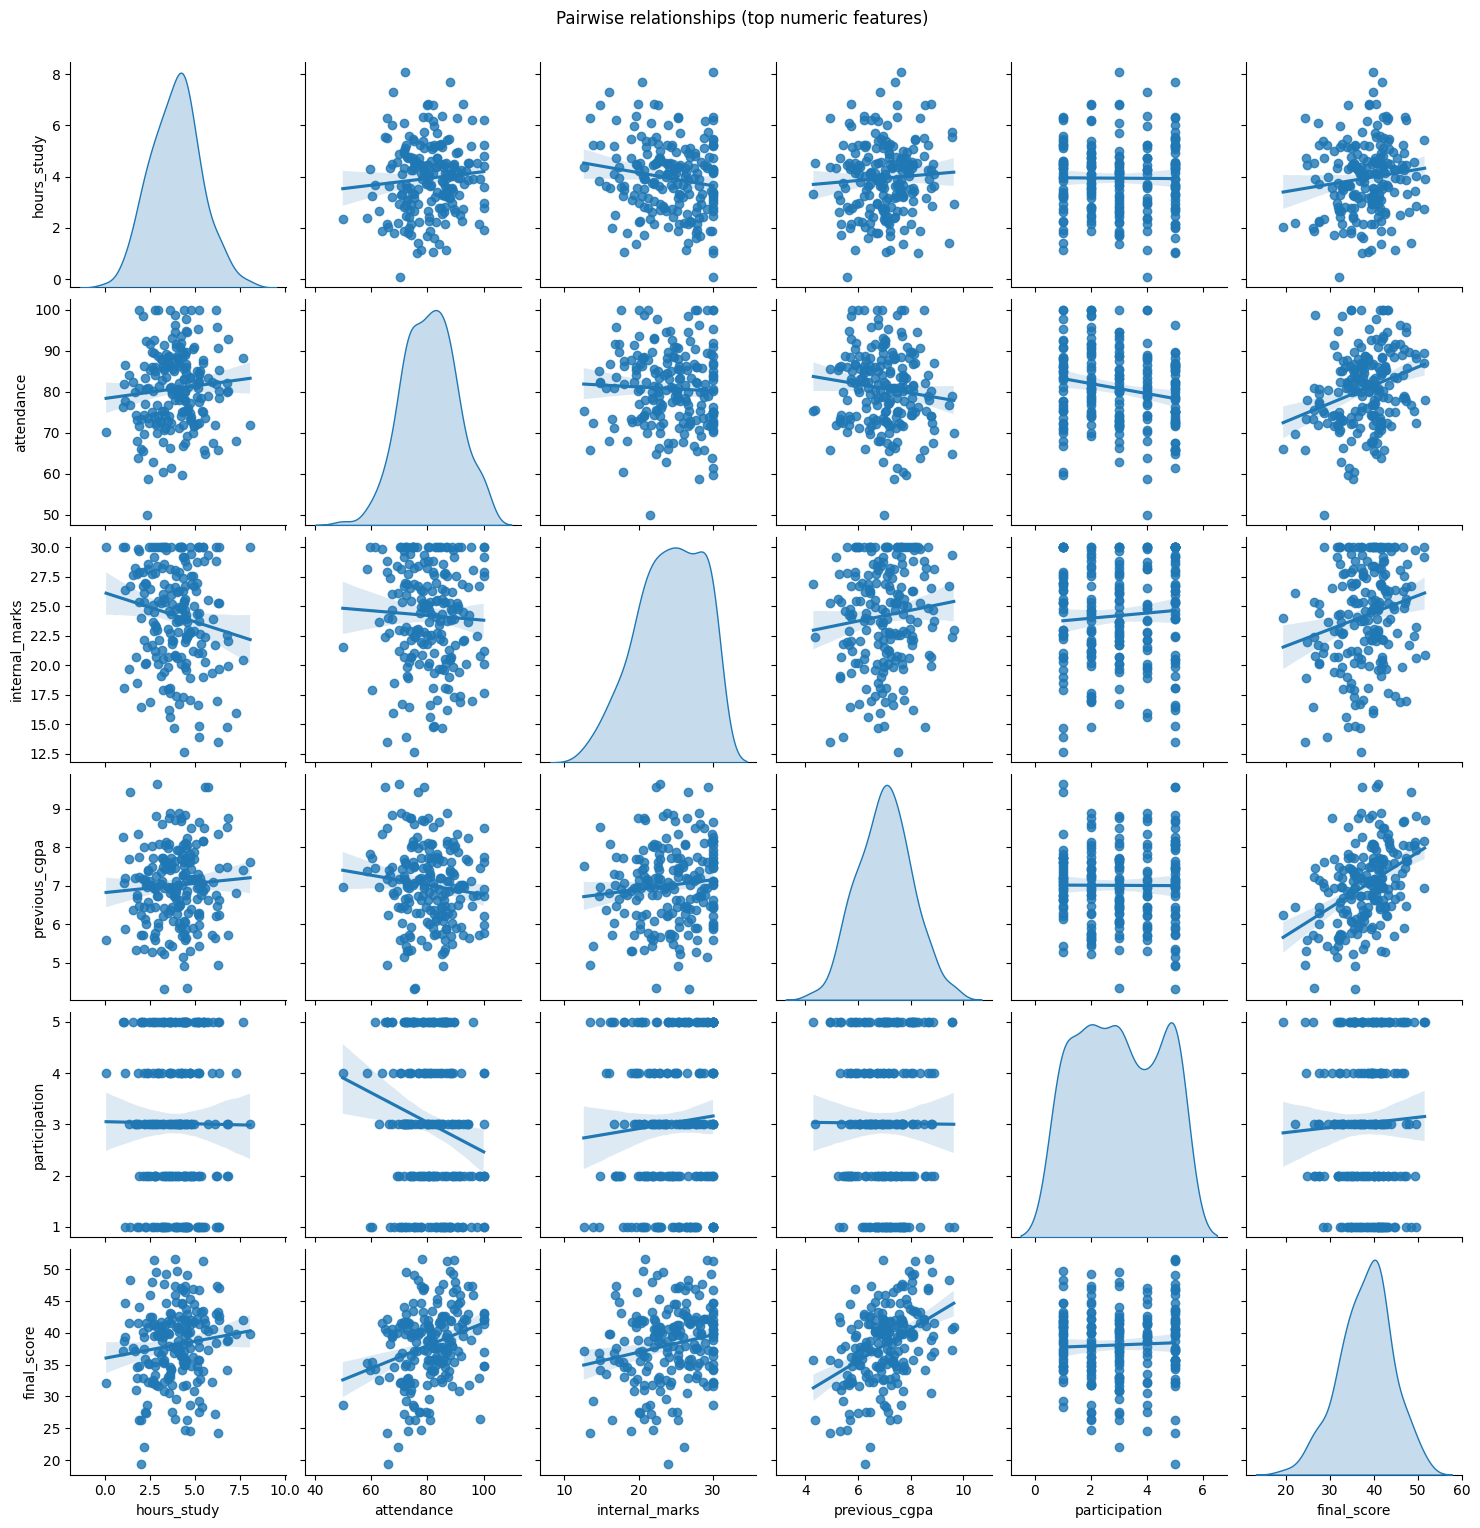

In [18]:
key_num = num_cols.copy()
if target_col in key_num: key_num.remove(target_col)
key_num = key_num[:5]

sns.pairplot(df[key_num + [target_col]].dropna(), kind="reg", diag_kind="kde")
plt.suptitle("Pairwise relationships (top numeric features)", y=1.02)
plt.show()

In [28]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [41]:
df = pd.get_dummies(df, drop_first=True)

In [29]:
# Split data
X = df.drop("final_score", axis=1)
y = df["final_score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [33]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [34]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n🔹 {model_name} Performance")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))

evaluate_model(y_test, y_pred, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")


🔹 Linear Regression Performance
MAE: 2.708036470689875
MSE: 10.614187967884838
R2 Score: 0.597803904995639

🔹 Random Forest Performance
MAE: 2.649565417458491
MSE: 10.665681546251983
R2 Score: 0.5958526943896341


#### Model Comparison Table

In [42]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_rf)
    ]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.597804
1      Random Forest  0.595853


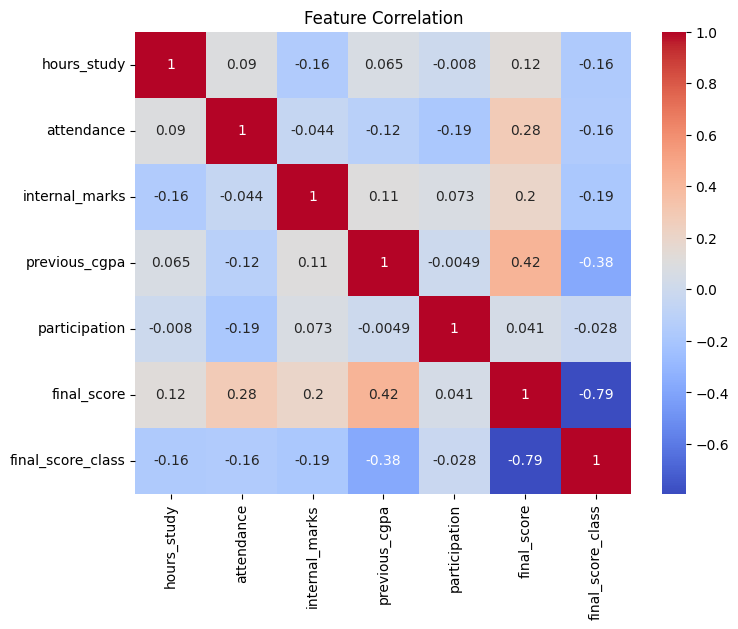

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

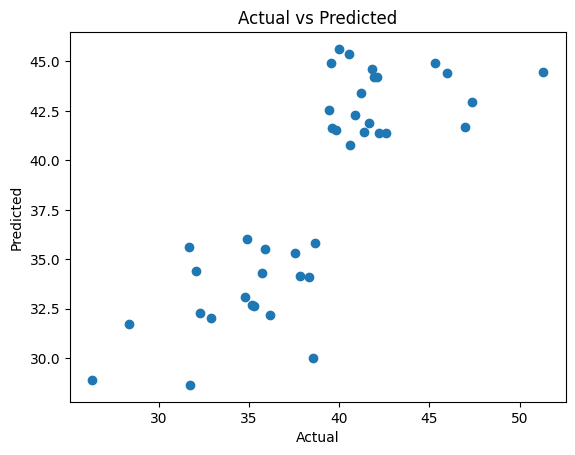

In [37]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

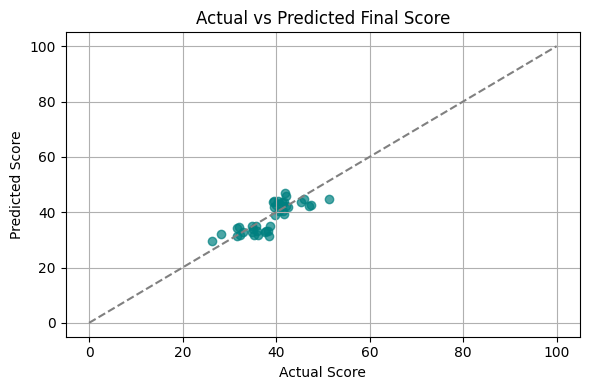

In [39]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([0, 100], [0, 100], '--', color='gray')
plt.title("Actual vs Predicted Final Score")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Save Model

In [43]:
pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))